# Single-Asset Timing with Trend Pullbacks and vectorbt

This notebook builds a single-asset timing signal: trade long when the trend is positive and the residual is temporarily cheap. The decomposition is the rule input, not an after-the-fact chart: `trend_slope` gates direction and `residual_z` defines the pullback.

It runs through a transparent pandas backtest first and then shows how to route the same signal to vectorbt.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ"], start="2016-01-01", cache_dir=DATA_CACHE)
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
entries, exits = trend_pullback_signals(prices, features, residual_entry_z=-1.0, residual_exit_z=0.25)
result = backtest_long_short_signals(prices, entries, exits, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,1.026423
cagr,0.070515
volatility,0.094885
sharpe,0.765487
max_drawdown,-0.187552
calmar,0.375973
hit_rate,0.176876
average_turnover,0.009954
average_gross_exposure,0.308959
fee_bps,1.000000


## Decomposition rule map

The rule deliberately uses only two components. Cycle features are left out here so the notebook can isolate whether trend plus residual timing adds anything before extra parameters are introduced.

In [3]:
pd.DataFrame([
    {"component": "trend", "feature": "trend_slope > 0", "rule_role": "permission to be long", "strategy_effect": "avoid buying pullbacks inside a falling decomposed trend"},
    {"component": "residual", "feature": "residual_z < -1.0", "rule_role": "entry trigger", "strategy_effect": "buy only when price is below the modeled trend/cycle structure"},
    {"component": "residual", "feature": "residual_z > 0.25", "rule_role": "exit trigger", "strategy_effect": "leave after the pullback mean-reverts toward the modeled path"},
    {"component": "season / cycle", "feature": "not used", "rule_role": "future extension", "strategy_effect": "inspect before adding a cycle-timing parameter"},
])

,component,feature,rule_role,strategy_effect
0,trend,trend_slope > 0,permission to be long,avoid buying pullbacks inside a falling decomp...
1,residual,residual_z < -1.0,entry trigger,buy only when price is below the modeled trend...
2,residual,residual_z > 0.25,exit trigger,leave after the pullback mean-reverts toward t...
3,season / cycle,not used,future extension,inspect before adding a cycle-timing parameter


## Visualization: decomposition inputs behind the signal

The top panel compares price with the walk-forward trend level. The middle panel shows the residual z-score bands that create entries and exits. The bottom panel shows the resulting target weight after the signal has consumed those features.

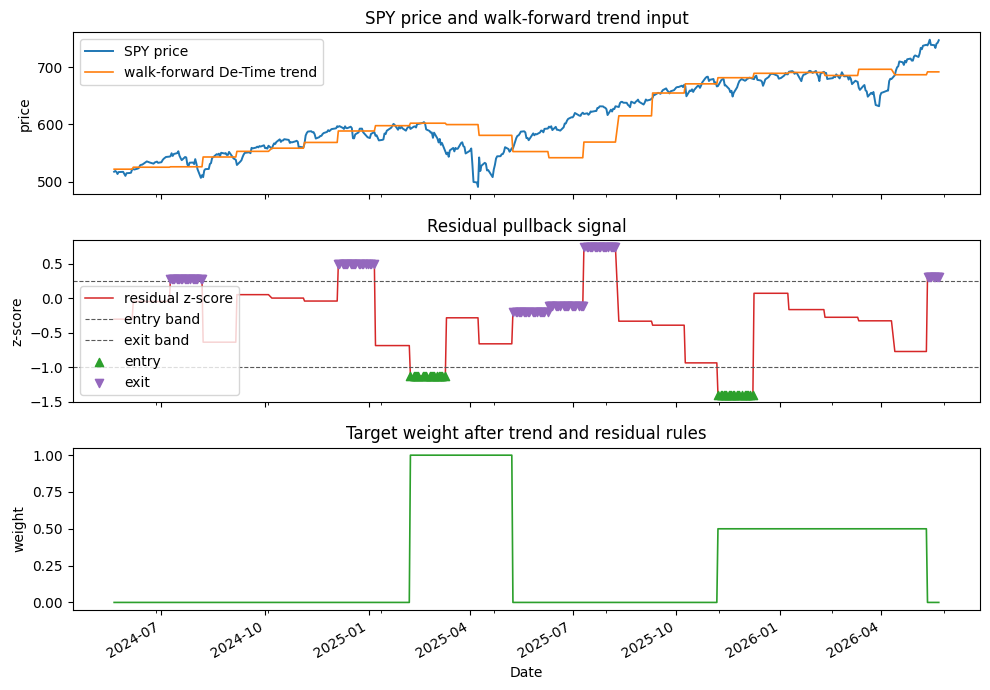

In [4]:
asset = "SPY"
window = prices.index[-504:]
price_line = prices.loc[window, asset]
trend_level = np.exp(features["trend"][asset]).reindex(window)
residual_z = features["residual_z"][asset].reindex(window)
position = result.weights[asset].reindex(window)
entry_points = entries.loc[window, asset].fillna(False).astype(bool)
exit_points = exits.loc[window, asset].fillna(False).astype(bool)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
price_line.plot(ax=axes[0], color="tab:blue", linewidth=1.4, label="SPY price")
trend_level.plot(ax=axes[0], color="tab:orange", linewidth=1.2, label="walk-forward De-Time trend")
axes[0].set_title("SPY price and walk-forward trend input")
axes[0].set_ylabel("price")
axes[0].legend(loc="best")

residual_z.plot(ax=axes[1], color="tab:red", linewidth=1.1, label="residual z-score")
for level, label in [(-1.0, "entry band"), (0.25, "exit band")]:
    axes[1].axhline(level, color="0.35", linestyle="--", linewidth=0.8, label=label)
axes[1].scatter(entry_points[entry_points].index, residual_z.loc[entry_points[entry_points].index], marker="^", color="tab:green", s=35, zorder=3, label="entry")
axes[1].scatter(exit_points[exit_points].index, residual_z.loc[exit_points[exit_points].index], marker="v", color="tab:purple", s=35, zorder=3, label="exit")
axes[1].set_title("Residual pullback signal")
axes[1].set_ylabel("z-score")
axes[1].legend(loc="best")

position.plot(ax=axes[2], color="tab:green", linewidth=1.2, title="Target weight after trend and residual rules")
axes[2].set_ylabel("weight")
plt.tight_layout()
plt.show()

## Visualization: SPY signal overlay

Entries and exits are drawn on recent SPY prices to make the trend-pullback timing rule inspectable.

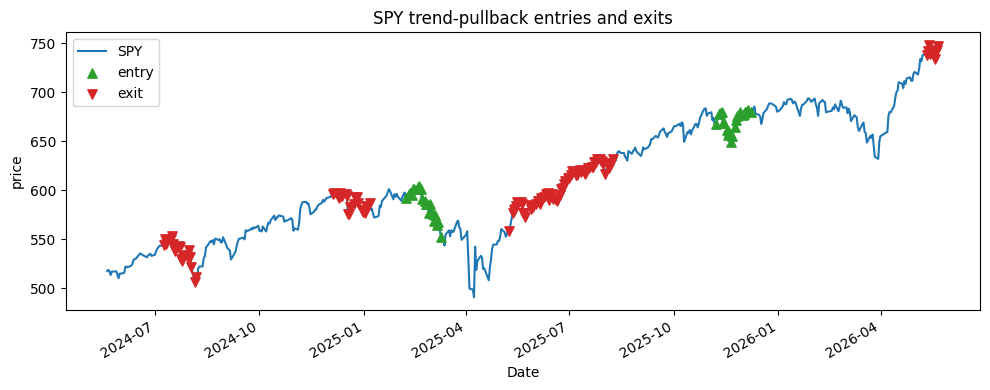

In [5]:
asset = "SPY"
window = prices.index[-504:]
price_line = prices.loc[window, asset]
entry_points = entries.loc[window, asset].fillna(False).astype(bool)
exit_points = exits.loc[window, asset].fillna(False).astype(bool)
fig, ax = plt.subplots(figsize=(10, 4))
price_line.plot(ax=ax, color="tab:blue", linewidth=1.5, title="SPY trend-pullback entries and exits")
ax.scatter(entry_points[entry_points].index, price_line.loc[entry_points[entry_points].index], marker="^", color="tab:green", s=45, label="entry", zorder=3)
ax.scatter(exit_points[exit_points].index, price_line.loc[exit_points[exit_points].index], marker="v", color="tab:red", s=45, label="exit", zorder=3)
ax.set_ylabel("price")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


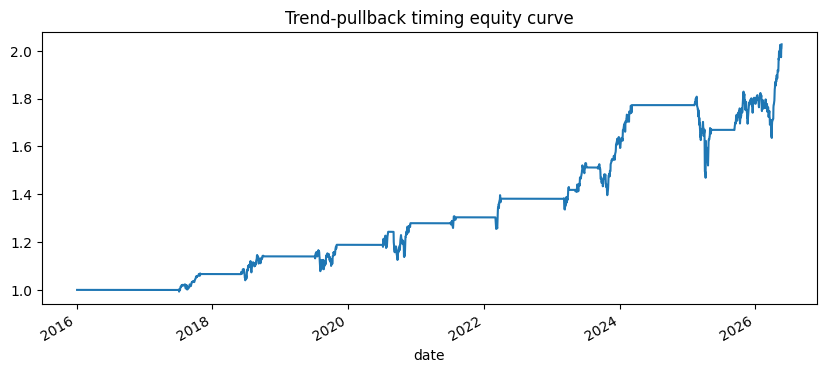

In [6]:
ax = result.equity.plot(figsize=(10, 4), title="Trend-pullback timing equity curve")
ax.set_xlabel("date")
plt.show()

## Visualization: drawdown and trading intensity

The equity curve is paired with underwater drawdown and turnover to reveal risk and implementation pressure.

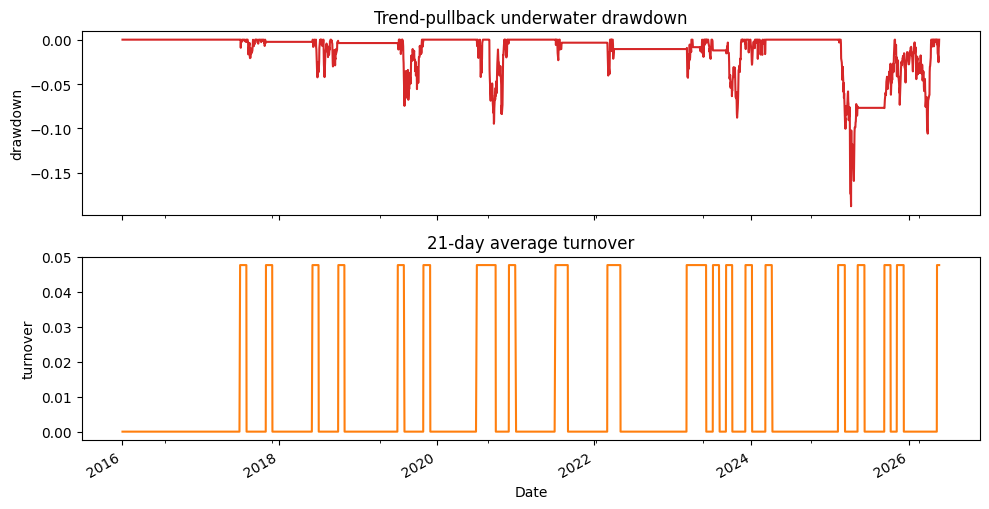

In [7]:
drawdown = result.equity / result.equity.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
drawdown.plot(ax=axes[0], color="tab:red", title="Trend-pullback underwater drawdown")
result.turnover.rolling(21, min_periods=1).mean().plot(ax=axes[1], color="tab:orange", title="21-day average turnover")
axes[0].set_ylabel("drawdown")
axes[1].set_ylabel("turnover")
plt.tight_layout()
plt.show()


## Optional: vectorbt adapter

Install vectorbt first if needed. The same entry/exit matrices can be passed to `Portfolio.from_signals` through the adapter.

In [8]:
from examples.quant_trading.frameworks import run_vectorbt_from_signals

# portfolio = run_vectorbt_from_signals(prices, entries, exits, fees=0.0001, slippage=0.0002)
# portfolio.stats()